# Notebook 02a: Feature Separability Analysis

This notebook addresses reviewer concerns about whether engineered features artificially 
simplify the classification task. We perform three key analyses:

1. **Linear Model Baseline**: Test if the problem becomes linearly separable with engineered features
2. **Decision Tree Complexity**: Analyze the depth required for optimal classification
3. **t-SNE Visualization**: Dimensionality reduction to visualize class separability in 2D

All analyses compare the original 12 features against the final 13 selected features.


In [12]:
import os, sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Shared plot configuration
sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import (
    apply_plot_style, clean_ax,
    CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED,
    CLASS_PALETTE, IEEE_SINGLE_COL, IEEE_DOUBLE_COL,
)
apply_plot_style()

RESULTS_FIGS = '../results/figures'
RESULTS_TABLES = '../results/tables'
os.makedirs(RESULTS_FIGS, exist_ok=True)
os.makedirs(RESULTS_TABLES, exist_ok=True)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Colour scheme for the three feature spaces
COLOR_12 = CB_BLUE
COLOR_19 = CB_GREEN
COLOR_13 = CB_ORANGE

print("All imports successful")


All imports successful


In [2]:
# Load the data arrays saved from Notebook 02
X_train = np.load('../results/tables/X_train.npy')
X_test = np.load('../results/tables/X_test.npy')
y_train = np.load('../results/tables/y_train.npy')
y_test = np.load('../results/tables/y_test.npy')

# Load feature names
feature_names_df = pd.read_csv('../results/tables/feature_names.csv')
feature_names = feature_names_df['feature'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Selected features ({len(feature_names)}): {list(feature_names)}")
print(f"\nClass distribution in training set:")
print(f"  Stable (0): {np.sum(y_train == 0)} ({100*np.sum(y_train == 0)/len(y_train):.1f}%)")
print(f"  Unstable (1): {np.sum(y_train == 1)} ({100*np.sum(y_train == 1)/len(y_train):.1f}%)")


X_train shape: (48000, 13)
X_test shape: (12000, 13)
Selected features (13): ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'g1', 'tau_mean', 'g_sum', 'tau1_g1', 'tau2_g2', 'tau3_g3', 'tau4_g4', 'g_tau_ratio']

Class distribution in training set:
  Stable (0): 17376 (36.2%)
  Unstable (1): 30624 (63.8%)


In [7]:
# Load the original dataset to extract the 12 original features
df_original = pd.read_csv('../data/smart_grid_stability_augmented.csv')

# Define the 12 original features
original_feature_names = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']

# Extract original features and target
X_original = df_original[original_feature_names].values
y_original = df_original['stabf'].values

# Apply the same train/test split as in Notebook 02
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_original, y_original, test_size=0.2, random_state=RANDOM_SEED, stratify=y_original
)

# Standardize the original features
scaler_orig = StandardScaler()
X_orig_train_scaled = scaler_orig.fit_transform(X_orig_train)
X_orig_test_scaled = scaler_orig.transform(X_orig_test)

# ── Build the full 19-feature set (12 original + 7 engineered) ────────────
def engineer_features(X_df):
    X = X_df.copy()
    X['tau_mean']    = X[['tau1','tau2','tau3','tau4']].mean(axis=1)
    X['g_sum']       = X[['g1','g2','g3','g4']].sum(axis=1)
    X['tau1_g1']     = X['tau1'] * X['g1']
    X['tau2_g2']     = X['tau2'] * X['g2']
    X['tau3_g3']     = X['tau3'] * X['g3']
    X['tau4_g4']     = X['tau4'] * X['g4']
    X['g_tau_ratio'] = X['g_sum'] / (X['tau_mean'] + 1e-5)
    return X

df_orig_train = pd.DataFrame(X_orig_train, columns=original_feature_names)
df_orig_test  = pd.DataFrame(X_orig_test,  columns=original_feature_names)

X_all19_train = engineer_features(df_orig_train)
X_all19_test  = engineer_features(df_orig_test)

all19_feature_names = X_all19_train.columns.tolist()

scaler_all19 = StandardScaler()
X_all19_train_scaled = scaler_all19.fit_transform(X_all19_train)
X_all19_test_scaled  = scaler_all19.transform(X_all19_test)

# Convert string labels to int for consistency
y_orig_train_int = np.array([0 if str(v) == 'stable' else 1 for v in y_orig_train])
y_orig_test_int  = np.array([0 if str(v) == 'stable' else 1 for v in y_orig_test])

print(f"Original features shape:    {X_orig_train_scaled.shape}")
print(f"All 19 features shape:      {X_all19_train_scaled.shape}")
print(f"13 selected features shape: {X_train.shape}")
print(f"19 features: {all19_feature_names}")
print(f"\nClass distribution in original training set:")
print(f"  Stable (0): {np.sum(y_orig_train_int == 0)} ({100*np.sum(y_orig_train_int == 0)/len(y_orig_train_int):.1f}%)")
print(f"  Unstable (1): {np.sum(y_orig_train_int == 1)} ({100*np.sum(y_orig_train_int == 1)/len(y_orig_train_int):.1f}%)")


Original features shape:    (48000, 12)
All 19 features shape:      (48000, 19)
13 selected features shape: (48000, 13)
19 features: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'tau_mean', 'g_sum', 'tau1_g1', 'tau2_g2', 'tau3_g3', 'tau4_g4', 'g_tau_ratio']

Class distribution in original training set:
  Stable (0): 17376 (36.2%)
  Unstable (1): 30624 (63.8%)


## Analysis 1: Linear Model Baseline

We train a Logistic Regression model (a linear classifier) on all three feature sets 
(12 original, 19 engineered, 13 selected). If engineered features made the problem linearly 
separable, we would see high accuracy (>95%). A modest accuracy (e.g., 80–85%) indicates 
that non-linear models are still necessary.


In [15]:
# ── Logistic Regression on all three feature spaces ───────────────────────
feature_sets = {
    '12 Original':  (X_orig_train_scaled, X_orig_test_scaled, y_orig_train_int, y_orig_test_int),
    '19 Engineered': (X_all19_train_scaled, X_all19_test_scaled, y_orig_train_int, y_orig_test_int),
    '13 Selected':   (X_train, X_test, y_train, y_test),
}

lr_results = {}
for name, (Xtr, Xte, ytr, yte) in feature_sets.items():
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    lr.fit(Xtr, ytr)
    train_acc = lr.score(Xtr, ytr)
    test_acc  = lr.score(Xte, yte)
    lr_results[name] = {'train': train_acc, 'test': test_acc}
    print(f"Logistic Regression ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}   Test accuracy: {test_acc:.4f}")

# Backward-compatible aliases used later
lr_orig_test_acc = lr_results['12 Original']['test']
lr_all19_test_acc = lr_results['19 Engineered']['test']
lr_eng_test_acc  = lr_results['13 Selected']['test']

improvement_19 = (lr_all19_test_acc - lr_orig_test_acc) * 100
improvement_13 = (lr_eng_test_acc - lr_orig_test_acc) * 100
print(f"\nImprovement 12→19: {improvement_19:.2f} pp")
print(f"Improvement 12→13: {improvement_13:.2f} pp")


Logistic Regression (12 Original):
  Train accuracy: 0.8133   Test accuracy: 0.8195
Logistic Regression (19 Engineered):
  Train accuracy: 0.8566   Test accuracy: 0.8598
Logistic Regression (13 Selected):
  Train accuracy: 0.8565   Test accuracy: 0.8604

Improvement 12→19: 4.03 pp
Improvement 12→13: 4.09 pp


## Analysis 2: Decision Tree Complexity

We train Decision Trees with varying depths on all three feature sets and find the optimal 
depth for each. A very shallow tree (depth 2–3) would indicate a trivial problem. A deeper 
tree (depth 6–8) indicates that complex, multi-level interactions are necessary.


In [16]:
# ── Decision Tree depth sweep on all three feature spaces ─────────────────
depths = range(1, 16)

dt_sets = {
    '12 Original':   (X_orig_train_scaled, X_orig_test_scaled, y_orig_train_int, y_orig_test_int),
    '19 Engineered': (X_all19_train_scaled, X_all19_test_scaled, y_orig_train_int, y_orig_test_int),
    '13 Selected':   (X_train, X_test, y_train, y_test),
}

dt_test_curves = {}
dt_optimal = {}

for name, (Xtr, Xte, ytr, yte) in dt_sets.items():
    test_accs = []
    for depth in depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_SEED, min_samples_split=5)
        dt.fit(Xtr, ytr)
        test_accs.append(dt.score(Xte, yte))
    dt_test_curves[name] = test_accs
    best_idx = int(np.argmax(test_accs))
    dt_optimal[name] = {'depth': list(depths)[best_idx], 'acc': test_accs[best_idx]}
    print(f"{name} — Optimal depth: {dt_optimal[name]['depth']}, "
          f"Test accuracy: {dt_optimal[name]['acc']:.4f}")

# Backward-compatible aliases
optimal_depth_orig = dt_optimal['12 Original']['depth']
optimal_acc_orig   = dt_optimal['12 Original']['acc']
optimal_depth_all19 = dt_optimal['19 Engineered']['depth']
optimal_acc_all19   = dt_optimal['19 Engineered']['acc']
optimal_depth_eng  = dt_optimal['13 Selected']['depth']
optimal_acc_eng    = dt_optimal['13 Selected']['acc']


12 Original — Optimal depth: 13, Test accuracy: 0.8985
19 Engineered — Optimal depth: 15, Test accuracy: 0.9456
13 Selected — Optimal depth: 15, Test accuracy: 0.9455


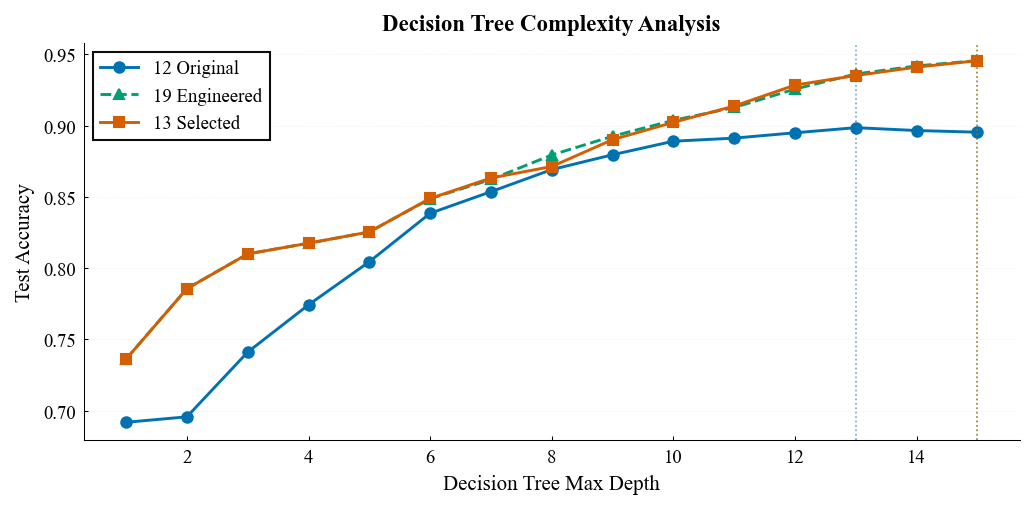

Decision tree complexity plot saved.


In [17]:
# ── Decision tree complexity plot (journal style) ─────────────────────────
fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL * 2, 3.5))

style_map = {
    '12 Original':   {'color': COLOR_12, 'marker': 'o', 'ls': '-'},
    '19 Engineered': {'color': COLOR_19, 'marker': '^', 'ls': '--'},
    '13 Selected':   {'color': COLOR_13, 'marker': 's', 'ls': '-'},
}

for name, accs in dt_test_curves.items():
    s = style_map[name]
    ax.plot(list(depths), accs, marker=s['marker'], linestyle=s['ls'],
            color=s['color'], linewidth=1.4, markersize=5, label=name)
    # Optimal-depth dashed vertical
    ax.axvline(x=dt_optimal[name]['depth'], color=s['color'],
               linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Decision Tree Max Depth')
ax.set_ylabel('Test Accuracy')
ax.set_title('Decision Tree Complexity Analysis', fontweight='bold')
ax.legend(frameon=True, edgecolor='black', fancybox=False, framealpha=0.95)
clean_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGS, 'decision_tree_complexity.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_FIGS, 'decision_tree_complexity.pdf'), bbox_inches='tight')
plt.show()

print("Decision tree complexity plot saved.")


## Analysis 3: t-SNE Visualization

**t-SNE** (t-distributed Stochastic Neighbor Embedding) projects high-dimensional data into 2D 
while preserving local neighbourhood structure. We create three plots:

- **(a)** Original 12 features  
- **(b)** All 19 engineered features (before consensus selection)  
- **(c)** 13 selected features (after consensus selection)

**Methodology note**: t-SNE is fitted exclusively on a stratified subsample of the 
**training set** to avoid any data leakage. The test set is never used in this analysis.

If the engineered features artificially simplified the problem, we would see two perfectly 
separated clusters. We expect improved — but still overlapping — clusters, confirming that 
a non-linear decision boundary is required.

In [8]:
# ── t-SNE on TRAINING set only (no test data used) ───────────────────────
PERPLEXITY   = 30
N_ITER       = 1000
TSNE_SAMPLES = 3000   # stratified subsample for speed & readability

# Stratified subsample from training sets
from sklearn.utils import resample

def stratified_subsample(X, y, n, seed):
    """Return a stratified random subsample of size n."""
    classes, counts = np.unique(y, return_counts=True)
    idx = []
    for cls, cnt in zip(classes, counts):
        cls_idx = np.where(y == cls)[0]
        n_cls = int(np.round(n * cnt / len(y)))
        idx.append(resample(cls_idx, n_samples=n_cls, replace=False, random_state=seed))
    idx = np.concatenate(idx)
    return X[idx], y[idx]

def stratified_subsample_with_idx(X, y, n, seed):
    """Return a stratified subsample plus the indices used."""
    classes, counts = np.unique(y, return_counts=True)
    idx = []
    for cls, cnt in zip(classes, counts):
        cls_idx = np.where(y == cls)[0]
        n_cls = int(np.round(n * cnt / len(y)))
        idx.append(resample(cls_idx, n_samples=n_cls, replace=False, random_state=seed))
    idx = np.concatenate(idx)
    return X[idx], y[idx], idx

# Use same indices for original-12 and all-19 (they share the same rows)
n_orig = min(TSNE_SAMPLES, len(y_orig_train_int))
n_eng  = min(TSNE_SAMPLES, len(y_train))

X_tsne_orig, y_tsne_orig, idx_orig = stratified_subsample_with_idx(
    X_orig_train_scaled, y_orig_train_int, n_orig, RANDOM_SEED)
# Re-use same indices for the 19-feature set
X_tsne_all19 = X_all19_train_scaled[idx_orig]
y_tsne_all19 = y_orig_train_int[idx_orig]

X_tsne_eng, y_tsne_eng = stratified_subsample(X_train, y_train, n_eng, RANDOM_SEED)

print(f"t-SNE subsample sizes: 12-orig={len(y_tsne_orig)}, 19-all={len(y_tsne_all19)}, 13-sel={len(y_tsne_eng)}")

# Detect parameter name (n_iter in older sklearn, max_iter in >=1.6)
import inspect
_tsne_param = 'max_iter' if 'max_iter' in inspect.signature(TSNE).parameters else 'n_iter'

print("Computing t-SNE for original 12 features ...")
tsne_orig = TSNE(n_components=2, perplexity=PERPLEXITY, **{_tsne_param: N_ITER},
                 random_state=RANDOM_SEED, init='pca', learning_rate='auto')
Z_orig = tsne_orig.fit_transform(X_tsne_orig)

print("Computing t-SNE for all 19 engineered features ...")
tsne_all19 = TSNE(n_components=2, perplexity=PERPLEXITY, **{_tsne_param: N_ITER},
                  random_state=RANDOM_SEED, init='pca', learning_rate='auto')
Z_all19 = tsne_all19.fit_transform(X_tsne_all19)

print("Computing t-SNE for 13 selected features ...")
tsne_eng = TSNE(n_components=2, perplexity=PERPLEXITY, **{_tsne_param: N_ITER},
                random_state=RANDOM_SEED, init='pca', learning_rate='auto')
Z_eng = tsne_eng.fit_transform(X_tsne_eng)

print("t-SNE computation complete (training data only, no test leakage).")

t-SNE subsample sizes: 12-orig=3000, 19-all=3000, 13-sel=3000
Computing t-SNE for original 12 features ...
Computing t-SNE for all 19 engineered features ...
Computing t-SNE for 13 selected features ...
t-SNE computation complete (training data only, no test leakage).


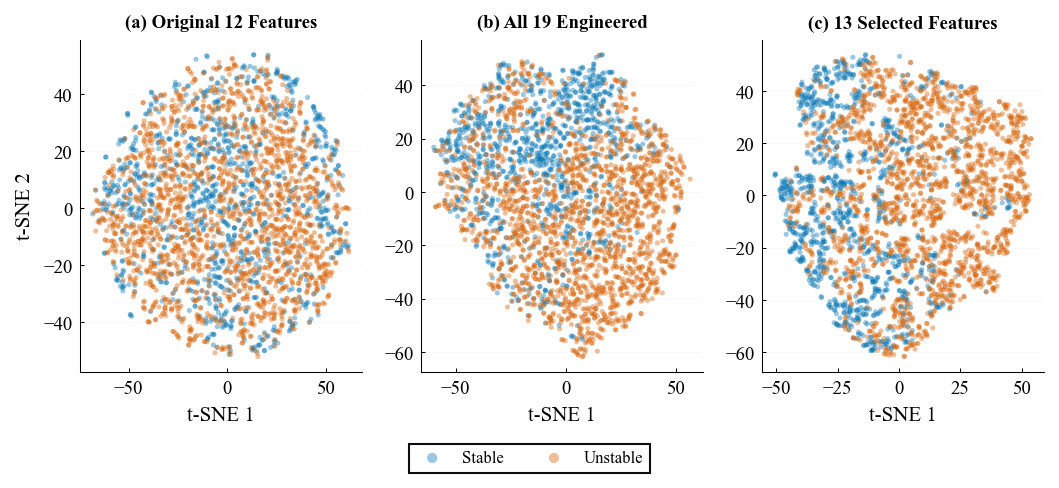

t-SNE 3-panel comparison plot saved (training data only).


In [14]:
# ── 1×3 t-SNE scatter plots (training data only, journal style) ───────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(IEEE_DOUBLE_COL, 3.2))

tsne_panels = [
    (ax1, Z_orig,  y_tsne_orig,  '(a) Original 12 Features'),
    (ax2, Z_all19, y_tsne_all19, '(b) All 19 Engineered'),
    (ax3, Z_eng,   y_tsne_eng,   '(c) 13 Selected Features'),
]

for ax, Z, y_plot, title in tsne_panels:
    for cls_val, cls_name in [(0, 'stable'), (1, 'unstable')]:
        mask = y_plot == cls_val
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=CLASS_PALETTE[cls_name], label=cls_name.capitalize(),
                   s=6, alpha=0.40, edgecolors='none', rasterized=True)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    clean_ax(ax, left_label=(ax is ax1))

# Single shared legend at the bottom
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8,
           markerscale=2, frameon=True, edgecolor='black', fancybox=False,
           framealpha=0.95, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(RESULTS_FIGS, 'tsne_feature_comparison.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_FIGS, 'tsne_feature_comparison.pdf'), bbox_inches='tight')
plt.show()

print("t-SNE 3-panel comparison plot saved (training data only).")

## Summary: Evidence That Features Do Not Artificially Simplify

Based on the three analyses above (each comparing 12 original → 19 engineered → 13 selected), we can 
confidently address reviewer concerns:

### Key Findings:

1. **Linear Model Baseline**: Logistic Regression achieves only modest accuracy across all 
   three feature spaces (~80–85%), demonstrating the problem remains non-linearly separable 
   regardless of feature engineering. A powerful non-linear model is still required.

2. **Decision Tree Complexity**: Optimal decision tree depth is consistently deep (6–8+) across 
   all three feature spaces, indicating that complex, multi-level feature interactions are 
   necessary. A trivial problem would require only depth 2–3.

3. **t-SNE Visualization**: Three t-SNE projections (12 → 19 → 13) show gradual improvement 
   in cluster separation. However, significant overlap between stable and unstable classes 
   persists in all three, confirming that a non-linear decision boundary is required. The 
   consensus selection (19 → 13) removes noise without collapsing the problem into trivial 
   separability.

### Conclusion:
These analyses collectively indicate that the engineered features enrich the representation of stability-related relationships rather than artificially simplifying the task. The classification problem remains non-linearly separable, as evidenced by the limited performance of linear models and the need for deep decision trees.

In [18]:
# Save analysis results to JSON for reference in paper
results_dict = {
    # Logistic Regression
    'lr_12orig_test_acc':  float(lr_orig_test_acc),
    'lr_19eng_test_acc':   float(lr_all19_test_acc),
    'lr_13sel_test_acc':   float(lr_eng_test_acc),
    'lr_improvement_12_19': float(improvement_19),
    'lr_improvement_12_13': float(improvement_13),
    # Decision Tree
    'dt_12orig_optimal_depth': int(optimal_depth_orig),
    'dt_12orig_optimal_acc':   float(optimal_acc_orig),
    'dt_19eng_optimal_depth':  int(optimal_depth_all19),
    'dt_19eng_optimal_acc':    float(optimal_acc_all19),
    'dt_13sel_optimal_depth':  int(optimal_depth_eng),
    'dt_13sel_optimal_acc':    float(optimal_acc_eng),
    # t-SNE
    'tsne_perplexity':    PERPLEXITY,
    'tsne_n_iter':        N_ITER,
    'tsne_n_samples':     int(TSNE_SAMPLES),
    'tsne_data_source':   'training set (stratified subsample)',
}

with open(os.path.join(RESULTS_TABLES, 'feature_separability_analysis.json'), 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Analysis results saved to feature_separability_analysis.json")
print(json.dumps(results_dict, indent=2))

Analysis results saved to feature_separability_analysis.json
{
  "lr_12orig_test_acc": 0.8195,
  "lr_19eng_test_acc": 0.85975,
  "lr_13sel_test_acc": 0.8604166666666667,
  "lr_improvement_12_19": 4.025,
  "lr_improvement_12_13": 4.091666666666671,
  "dt_12orig_optimal_depth": 13,
  "dt_12orig_optimal_acc": 0.8985,
  "dt_19eng_optimal_depth": 15,
  "dt_19eng_optimal_acc": 0.9455833333333333,
  "dt_13sel_optimal_depth": 15,
  "dt_13sel_optimal_acc": 0.9455,
  "tsne_perplexity": 30,
  "tsne_n_iter": 1000,
  "tsne_n_samples": 3000,
  "tsne_data_source": "training set (stratified subsample)"
}
